,Temperature [C],Voc [V]
0,46.88,0.893693
1,57.71,0.868536
2,63.12,0.854239
3,66.22,0.847340
4,68.32,0.843055
5,69.98,0.838087
6,71.34,0.832554
7,72.51,0.831733
8,73.50,0.827472
9,74.29,0.824746


/var/folders/gk/j7sbhfc93v5gxyqp6ltt1dqc0000gn/T/ipykernel_93319/1872674803.py:32: RuntimeWarning: invalid value encountered in log
  return (n * k_B * T / q) * np.log(1.0 + A * np.exp(Ea / (k_B * T)))


,Parameter,Value
0,n,1.591224e+00
1,A,7.547676e-09
2,Ea (eV),1.078621e+00


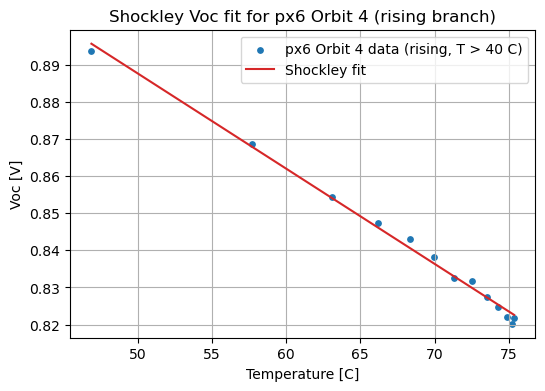

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import display

px6_file = '/Users/ruodongyang/Documents/Resilio_Sync/TUM Master Physik/Pervoskite Space(Master)/Data/ThermalCycling/TC_1709_50Cycle/TC_1909_IV/TC_log/pixel/px6_result.csv'
df_px6 = pd.read_csv(px6_file)

# Orbit 4 points while the temperature is rising above 40 C
orbit_4 = df_px6[df_px6['Cycle Number'] == 4].copy()
orbit_4 = orbit_4.sort_values('Timestamp[s]').reset_index(drop=True)
orbit_4 = orbit_4[orbit_4['Temperature [C]'] > 40].reset_index(drop=True)

temps_seq = orbit_4['Temperature [C]'].to_numpy()
if temps_seq.size == 0:
    raise ValueError('No Orbit 4 data above 40 C.')

drop_idx = np.where(np.diff(temps_seq) <= 0)[0]
if drop_idx.size > 0:
    stop = int(drop_idx[0] + 1)
    orbit_4 = orbit_4.iloc[:stop].reset_index(drop=True)

display(orbit_4[['Temperature [C]', 'Voc [V]']])

k_B = 1.380649e-23  # Boltzmann constant (J/K)
q = 1.602176634e-19  # Elementary charge (C)

def voc_model(temp_celsius, n, A, Ea_eV):
    T = temp_celsius + 273.15
    Ea = Ea_eV * q
    return (n * k_B * T / q) * np.log(1.0 + A * np.exp(Ea / (k_B * T)))

temps = orbit_4['Temperature [C]'].to_numpy()
voc_vals = orbit_4['Voc [V]'].to_numpy()

initial_guess = (1.5, 1e-6, 1.1)
popt, pcov = curve_fit(voc_model, temps, voc_vals, p0=initial_guess, maxfev=20000)

fit_table = pd.DataFrame(
    {
        'Parameter': ['n', 'A', 'Ea (eV)'],
        'Value': popt
    }
)

display(fit_table)

temp_grid = np.linspace(temps.min(), temps.max(), 200)
voc_fit = voc_model(temp_grid, *popt)

plt.figure(figsize=(6, 4))
plt.scatter(temps, voc_vals, s=15, label='px6 Orbit 4 data (rising, T > 40 C)')
plt.plot(temp_grid, voc_fit, color='tab:red', label='Shockley fit')
plt.xlabel('Temperature [C]')
plt.ylabel('Voc [V]')
plt.title('Shockley Voc fit for px6 Orbit 4 (rising branch)')
plt.grid(True)
plt.legend()
plt.show()


/var/folders/gk/j7sbhfc93v5gxyqp6ltt1dqc0000gn/T/ipykernel_93319/1598013152.py:18: RuntimeWarning: invalid value encountered in log
  return (n * k_B * T / q) * np.log(1.0 + A * np.exp(Ea / (k_B * T)))
/var/folders/gk/j7sbhfc93v5gxyqp6ltt1dqc0000gn/T/ipykernel_93319/1598013152.py:18: RuntimeWarning: overflow encountered in exp
  return (n * k_B * T / q) * np.log(1.0 + A * np.exp(Ea / (k_B * T)))


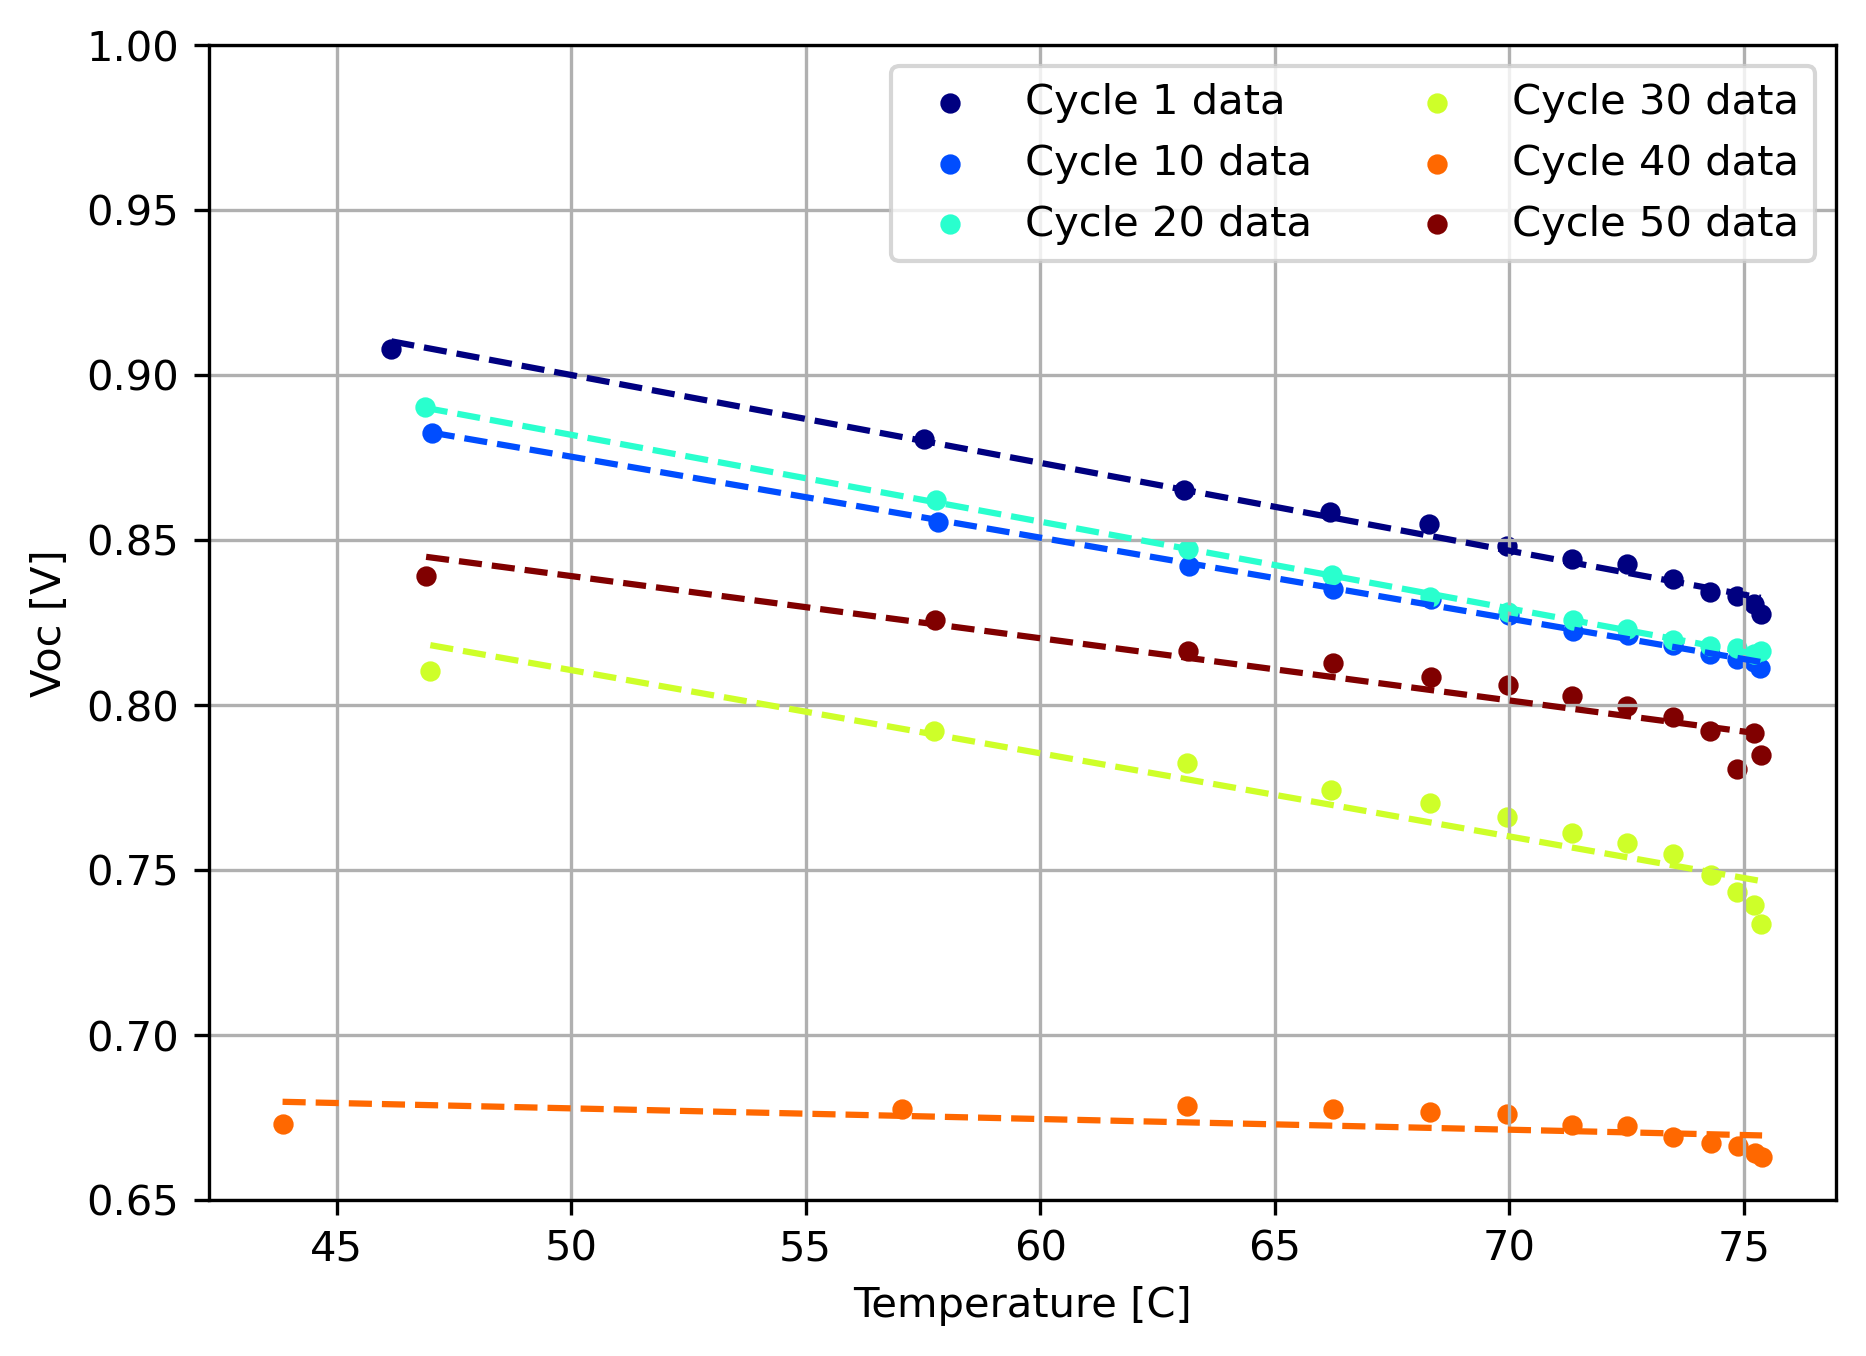

,Cycle,n,A,Ea (eV)
0,1,1.625206,5.536423e-09,1.083235
1,10,1.549711,1.052534e-08,1.076351
2,20,1.604651,5.452449e-09,1.079457
3,30,1.549264,6.348860e-09,1.048844
4,40,0.410879,1.080113e-04,1.904019
5,50,1.313153,5.849027e-08,1.102792


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

try:
    df_px6
except NameError:
    px6_file = '/Users/ruodongyang/Documents/Resilio_Sync/TUM Master Physik/Pervoskite Space(Master)/Data/ThermalCycling/TC_1709_50Cycle/TC_1909_IV/TC_log/pixel/px6_result.csv'
    df_px6 = pd.read_csv(px6_file)

k_B = 1.380649e-23  # Boltzmann constant (J/K)
q = 1.602176634e-19  # Elementary charge (C)

def voc_model(temp_celsius, n, A, Ea_eV):
    T = temp_celsius + 273.15
    Ea = Ea_eV * q
    return (n * k_B * T / q) * np.log(1.0 + A * np.exp(Ea / (k_B * T)))

def extract_rising_branch(df, cycle, min_temp=40):
    orbit = df[df['Cycle Number'] == cycle].copy()
    if orbit.empty:
        return None
    orbit = orbit.sort_values('Timestamp[s]').reset_index(drop=True)
    orbit = orbit[orbit['Temperature [C]'] > min_temp].reset_index(drop=True)
    temps_seq = orbit['Temperature [C]'].to_numpy()
    if temps_seq.size < 2:
        return None
    drop_idx = np.where(np.diff(temps_seq) <= 0)[0]
    if drop_idx.size > 0:
        orbit = orbit.iloc[: drop_idx[0] + 1].reset_index(drop=True)
    if orbit.shape[0] < 2:
        return None
    return orbit

target_cycles = [1, 10, 20, 30, 40, 50]
colors = plt.cm.jet(np.linspace(0, 1, len(target_cycles)))
fit_records = []

plt.figure(figsize=(7, 5), dpi = 300)
for cycle, color in zip(target_cycles, colors):
    branch = extract_rising_branch(df_px6, cycle)
    if branch is None:
        print(f"Cycle {cycle}: no rising data above 40 C, skipped.")
        continue
    temps = branch['Temperature [C]'].to_numpy()
    voc_vals = branch['Voc [V]'].to_numpy()
    try:
        popt, _ = curve_fit(voc_model, temps, voc_vals, p0=(1.5, 1e-6, 1.1), maxfev=20000)
    except RuntimeError:
        print(f"Cycle {cycle}: fit failed, skipped.")
        continue
    fit_records.append({'Cycle': cycle, 'n': popt[0], 'A': popt[1], 'Ea (eV)': popt[2]})
    temp_grid = np.linspace(temps.min(), temps.max(), 200)
    plt.scatter(temps, voc_vals, s=15, color=color, label=f'Cycle {cycle} data')
    plt.plot(temp_grid, voc_model(temp_grid, *popt), color=color, linestyle='--')

if not fit_records:
    raise ValueError('No cycles were successfully fitted.')

plt.xlabel('Temperature [C]')
plt.ylabel('Voc [V]')
plt.ylim(0.65, 1)
plt.grid(True)
plt.legend(ncol=2)
plt.show()

fit_summary = pd.DataFrame(fit_records)
fit_summary


/var/folders/gk/j7sbhfc93v5gxyqp6ltt1dqc0000gn/T/ipykernel_68831/872789943.py:18: RuntimeWarning: invalid value encountered in log
  return (n * k_B * T / q) * np.log(1.0 + A * np.exp(Ea / (k_B * T)))
/var/folders/gk/j7sbhfc93v5gxyqp6ltt1dqc0000gn/T/ipykernel_68831/872789943.py:18: RuntimeWarning: overflow encountered in exp
  return (n * k_B * T / q) * np.log(1.0 + A * np.exp(Ea / (k_B * T)))


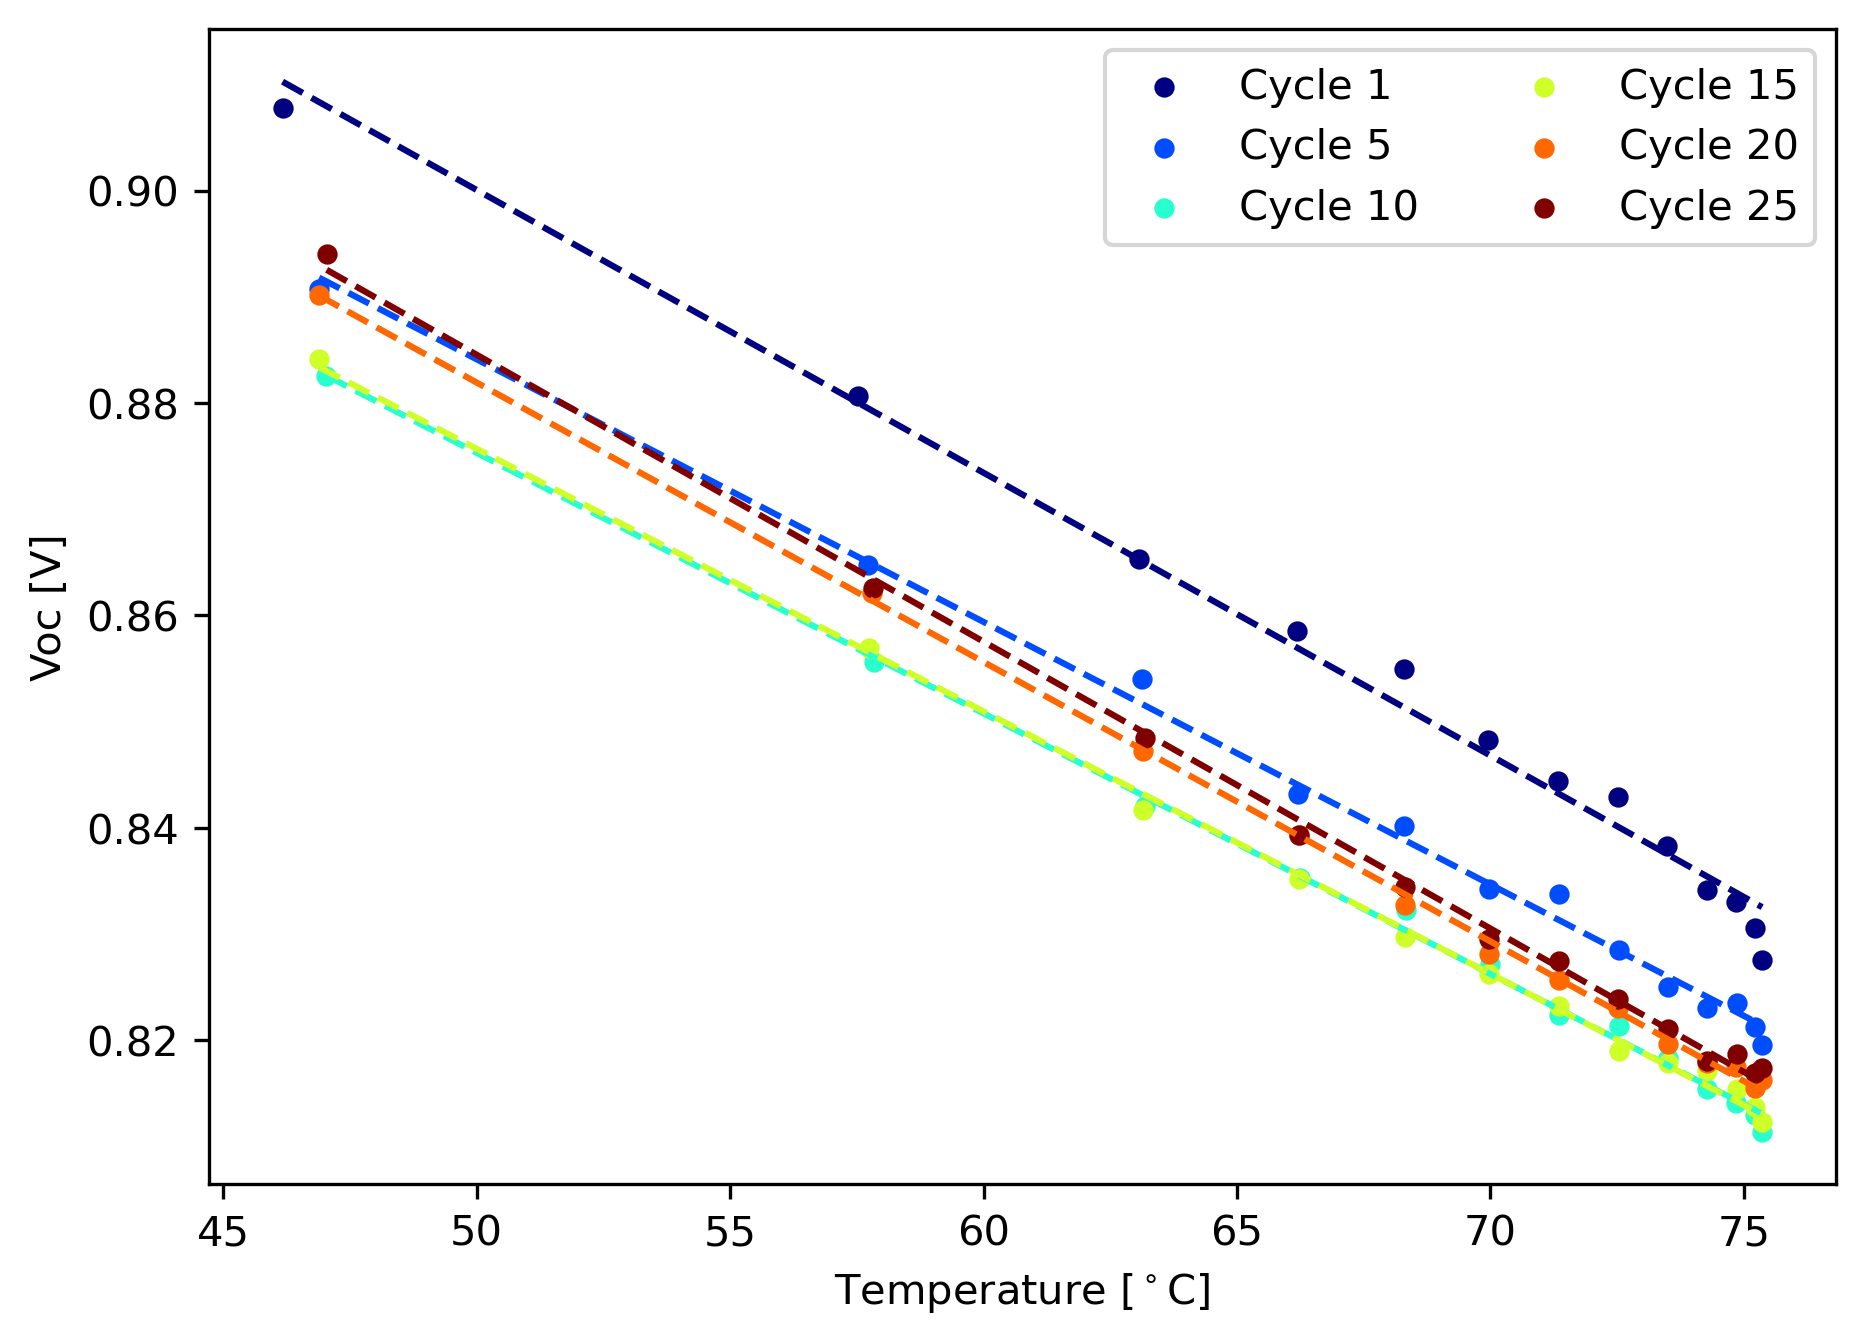

,Cycle,n,A,Ea (eV)
0,1,1.625206,5.536423e-09,1.083235
1,5,1.569468,1.148833e-08,1.072417
2,10,1.549711,1.052534e-08,1.076351
3,15,1.550028,9.179686e-09,1.080297
4,20,1.604651,5.452449e-09,1.079457
5,25,1.630913,4.496183e-09,1.077581


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

try:
    df_px6
except NameError:
    px6_file = '/Users/ruodongyang/Documents/Resilio_Sync/TUM Master Physik/Pervoskite Space(Master)/Data/ThermalCycling/TC_1709_50Cycle/TC_1909_IV/TC_log/pixel/px6_result.csv'
    df_px6 = pd.read_csv(px6_file)

k_B = 1.380649e-23  # Boltzmann constant (J/K)
q = 1.602176634e-19  # Elementary charge (C)

def voc_model(temp_celsius, n, A, Ea_eV):
    T = temp_celsius + 273.15
    Ea = Ea_eV * q
    return (n * k_B * T / q) * np.log(1.0 + A * np.exp(Ea / (k_B * T)))

def extract_rising_branch(df, cycle, min_temp=40):
    orbit = df[df['Cycle Number'] == cycle].copy()
    if orbit.empty:
        return None
    orbit = orbit.sort_values('Timestamp[s]').reset_index(drop=True)
    orbit = orbit[orbit['Temperature [C]'] > min_temp].reset_index(drop=True)
    temps_seq = orbit['Temperature [C]'].to_numpy()
    if temps_seq.size < 2:
        return None
    drop_idx = np.where(np.diff(temps_seq) <= 0)[0]
    if drop_idx.size > 0:
        orbit = orbit.iloc[: drop_idx[0] + 1].reset_index(drop=True)
    if orbit.shape[0] < 2:
        return None
    return orbit

target_cycles = [1, 5, 10, 15, 20, 25]
colors = plt.cm.jet(np.linspace(0, 1, len(target_cycles)))
fit_records = []

plt.figure(figsize=(7, 5), dpi=300)
for cycle, color in zip(target_cycles, colors):
    branch = extract_rising_branch(df_px6, cycle)
    if branch is None:
        print(f"Cycle {cycle}: no rising data above 40 C, skipped.")
        continue
    temps = branch['Temperature [C]'].to_numpy()
    voc_vals = branch['Voc [V]'].to_numpy()
    try:
        popt, _ = curve_fit(voc_model, temps, voc_vals, p0=(1.5, 1e-6, 1.1), maxfev=20000)
    except RuntimeError:
        print(f"Cycle {cycle}: fit failed, skipped.")
        continue
    fit_records.append({'Cycle': cycle, 'n': popt[0], 'A': popt[1], 'Ea (eV)': popt[2]})
    temp_grid = np.linspace(temps.min(), temps.max(), 200)
    plt.scatter(temps, voc_vals, s=15, color=color, label=f'Cycle {cycle}')
    plt.plot(temp_grid, voc_model(temp_grid, *popt), color=color, linestyle='--')

if not fit_records:
    raise ValueError('No cycles were successfully fitted.')

plt.xlabel('Temperature [$^\circ$C]')
plt.ylabel('Voc [V]')
#plt.title('Shockley fits for cycles 1–25 (rising branch, T > 40 C)')
#plt.grid(True)
plt.legend(ncol=2)
plt.show()

fit_summary = pd.DataFrame(fit_records)
fit_summary
